# MARKDOWN - OBETIVOS DO PROJETO

# 1. BIBLIOTECAS:

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. DATASET:

In [122]:
df = pd.read_csv('survey_results_public.csv')
df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


In [123]:
# INFORMAÇÕES BÁSICAS DO DATASET:
print("INFORMAÇÕES BÁSICAS DO DATASET")
print("="*50)

print(f"\n Shape do dataset: {df.shape}")
print(f"   • {df.shape[0]} registros")
print(f"   • {df.shape[1]} colunas")

print(f"\n Tipos de dados:")
print(df.dtypes)

print(f"\n Informações gerais:")
print(df.info())

print(f"\n Estatísticas descritivas:")
print(df.describe())

print(f"\n Valores nulos por coluna:")
print(df.isnull().sum())

INFORMAÇÕES BÁSICAS DO DATASET

 Shape do dataset: (89184, 84)
   • 89184 registros
   • 84 colunas

 Tipos de dados:
ResponseId               int64
Q120                    object
MainBranch              object
Age                     object
Employment              object
                        ...   
ProfessionalTech        object
Industry                object
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
Length: 84, dtype: object

 Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89184 non-null  int64  
 1   Q120                                 89184 non-null  object 
 2   MainBranch                           89184 non-null  object 
 3   Age                                  89184 non-nu

# 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA):

## 3.1. DISTRIBUIÇÃO DO SALÁRIO ANUAL CONVERTIDO (TARGET) - ConvertedCompYearly:

In [124]:
# DROP NO ID:
df.drop(columns=['ResponseId'], inplace=True)

In [125]:
# A. VALORES AUSENTES:
print("Quantidade de valores ausentes:", df['ConvertedCompYearly'].isnull().sum())
print("Porcentagem de valores ausentes:", 
      (df['ConvertedCompYearly'].isnull().sum() / len(df)) * 100)

Quantidade de valores ausentes: 41165
Porcentagem de valores ausentes: 46.15738249013276


In [126]:
# B. MEDIDAS DESCRITIVAS:
df['ConvertedCompYearly'].describe()

count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64

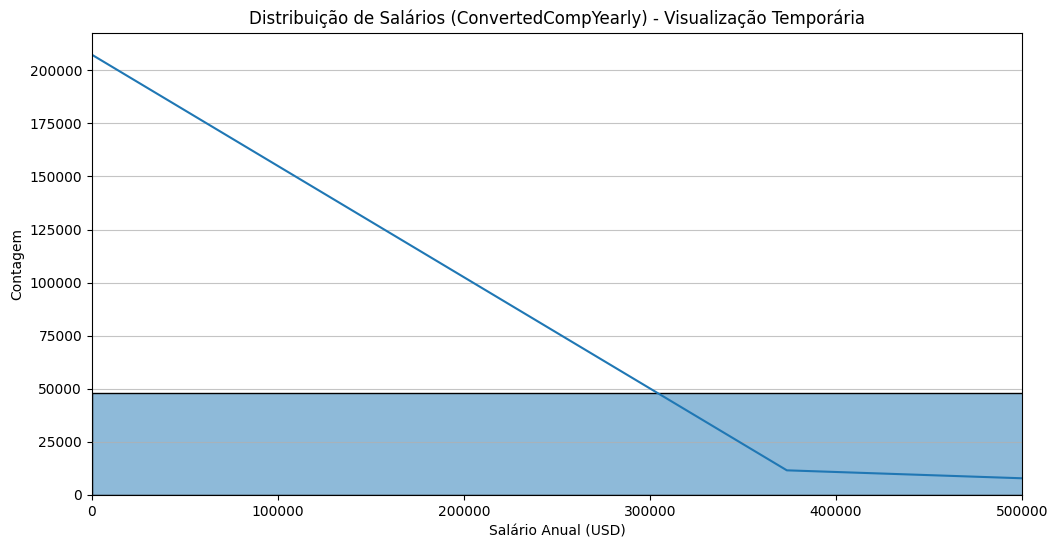

In [127]:
# C. HISTOGRAMA:
plt.figure(figsize=(12, 6))
sns.histplot(df['ConvertedCompYearly'].dropna(), bins=50, kde=True)
plt.title('Distribuição de Salários (ConvertedCompYearly) - Visualização Temporária')
plt.xlabel('Salário Anual (USD)')
plt.ylabel('Contagem')
plt.xlim(0, 500000)
plt.grid(axis='y', alpha=0.75)
plt.show()

Observações sobre o histograma:

- a. Limitamos o Eixo X (Temporariamente para Visualização):
    Definimos um limite máximo (U$500.000) para o eixo X para possibilitar a visulização da distribuição da maioria dos dados, mesmo que os outliers fiquem fora da visualização.
- b. O histograma revela uma distribuição altamente assimétrica, com a grande maioria dos salários concentrada na faixa mais baixa. A curva KDE (kde=True) é essencial para ver a forma da distribuição, que parece ter uma "cauda longa" para a direita, indicando a presença de salários mais altos

(0.0, 500000.0)

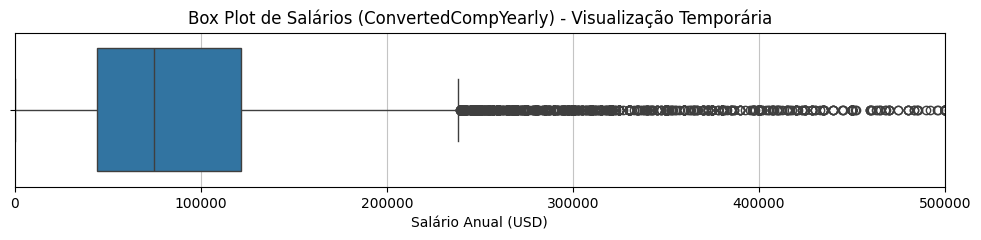

In [128]:
# D. BOXPLOT:
plt.figure(figsize=(12, 2))
sns.boxplot(x=df['ConvertedCompYearly'].dropna())
plt.title('Box Plot de Salários (ConvertedCompYearly) - Visualização Temporária')
plt.xlabel('Salário Anual (USD)')
plt.grid(axis='x', alpha=0.75)
plt.xlim(0, 500000)

Observações sobre o boxplot:

- a. A caixa representa o intervalo interquartil (IQR), onde 50% dos dados estão (aproximadamente entre U$5.000 e U$11.000)
- b. Há muitos pontos acima do whisker superior (Q3 + 1,5*IQR). O que pode ser um indício de outliers.  Isso confirma a presença de muitos salários extremamente altos que distorcem a distribuição

# 4. TRATAMENTO DE OUTLIERS E TRANSFORMAÇÃO DO TARGET:

In [129]:
# REMOVER AS LINHAS ONDE O SALÁRIO É NULO:
df_log = df.dropna(subset=['ConvertedCompYearly']).copy()

# TRANSFORMAR O TARGET (SALÁRIO) EM LOG:
df_log['ConvertedCompYearly_log'] = np.log1p(df_log['ConvertedCompYearly'])

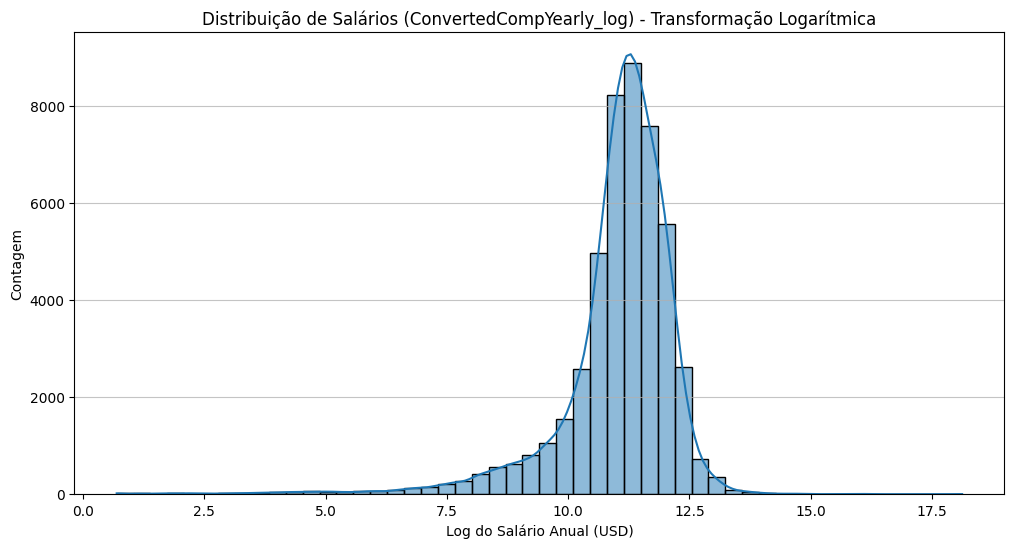

In [130]:
# HISTOGRAMA COM A TRANSFORMAÇÃO LOGARÍTMICA:
plt.figure(figsize=(12, 6))
sns.histplot(df_log['ConvertedCompYearly_log'], bins=50, kde=True)
plt.title('Distribuição de Salários (ConvertedCompYearly_log) - Transformação Logarítmica')
plt.xlabel('Log do Salário Anual (USD)')
plt.ylabel('Contagem')
plt.grid(axis='y', alpha=0.75)
plt.show()

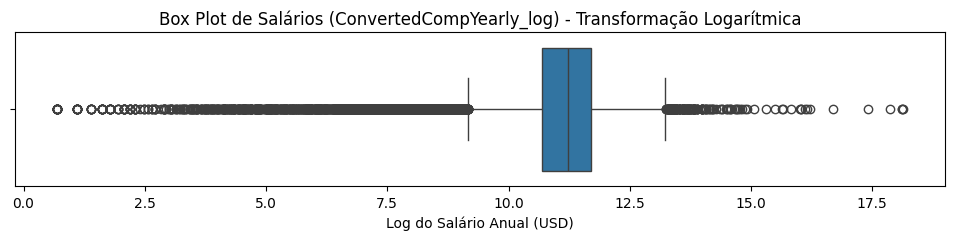

In [131]:
# BOXPLOT COM A TRANSFORMAÇÃO LOGARÍTMICA:
plt.figure(figsize=(12, 2))
sns.boxplot(x=df_log['ConvertedCompYearly_log'])
plt.title('Box Plot de Salários (ConvertedCompYearly_log) - Transformação Logarítmica')
plt.xlabel('Log do Salário Anual (USD)')
plt.show()

In [132]:
# DESCRIBE A VARIÁVEL ALVO TRANSFORMADA:
df_log['ConvertedCompYearly_log'].describe()

count    48019.000000
mean        11.019407
std          1.234126
min          0.693147
25%         10.689852
50%         11.224763
75%         11.708838
max         18.124314
Name: ConvertedCompYearly_log, dtype: float64

# 5. FEATURE ENGENEERING:

## 5.1. 'EdLevel':

In [133]:
# VALORES UNICOS NA COLUNA 'EdLevel':
df_log['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          22540
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       13045
Some college/university study without earning a degree                                 5654
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2297
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     2169
Associate degree (A.A., A.S., etc.)                                                    1596
Something else                                                                          496
Primary/elementary school                                                               222
Name: count, dtype: int64

In [134]:
# ORDEM DOS NÍVEIS DE EDUCAÇÃO:
ed_level_mapping = {
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree': 3,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 4,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 5,
    'Professional degree (JD, MD, etc.)': 6,
    'Other doctoral degree (Ph.D., Ed.D., etc.)': 7,
    'Something else': 0,
    'Prefer not to say': 0
}

In [135]:
# CRIAR UMA NOVA COLUNA COM OS NÍVEIS DE EDUCAÇÃO MAPEADOS:
df_log['EdLevel_numeric'] = df_log['EdLevel'].map(ed_level_mapping)
df_log['EdLevel_numeric'].value_counts()

EdLevel_numeric
4.0    22540
5.0    13045
2.0     5654
1.0     2169
0.0      496
Name: count, dtype: int64

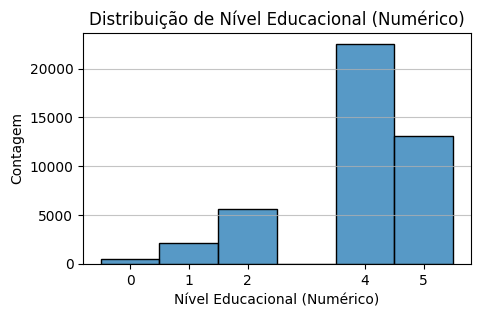

In [136]:
# DISTRIBUIÇÃO DO NÍVEL EDUCACIONAL (NUMÉRICO):
plt.figure(figsize=(5, 3))
sns.histplot(df_log['EdLevel_numeric'].dropna(), bins=len(ed_level_mapping) - 2, kde=False, discrete=True) # bins = número de categorias válidas
plt.title('Distribuição de Nível Educacional (Numérico)')
plt.xlabel('Nível Educacional (Numérico)')
plt.ylabel('Contagem')
plt.xticks(sorted(df_log['EdLevel_numeric'].dropna().unique())) # Para exibir os ticks nos números das categorias
plt.grid(axis='y', alpha=0.75)
plt.show()

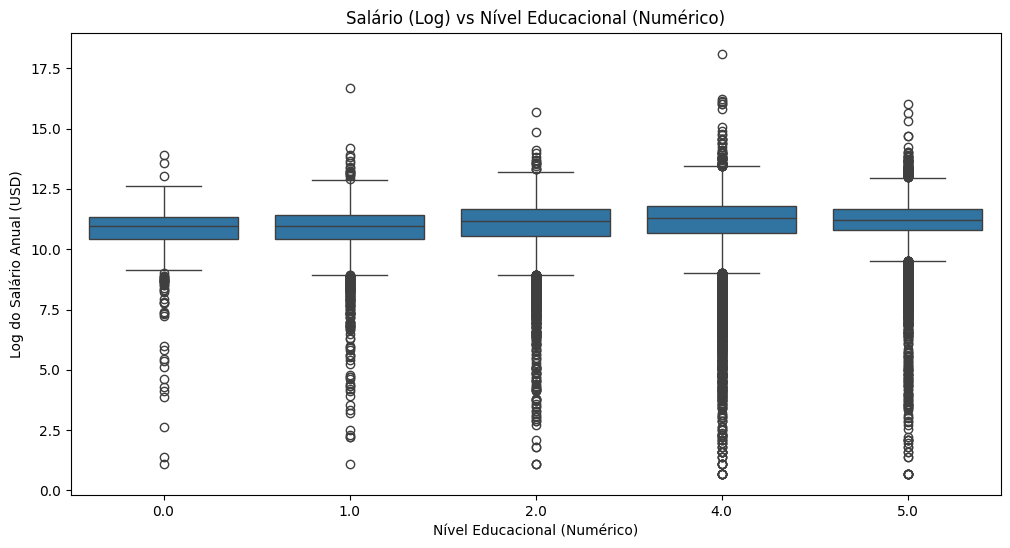

In [137]:
# BOXPLOT PARA A RELAÇÃO ENTRE NÍVEL EDUCACIONAL E SALÁRIO (LOG):
plt.figure(figsize=(12, 6))
sns.boxplot(x='EdLevel_numeric', y='ConvertedCompYearly_log', data=df_log.dropna(subset=['EdLevel_numeric']))
plt.title('Salário (Log) vs Nível Educacional (Numérico)')
plt.xlabel('Nível Educacional (Numérico)')
plt.ylabel('Log do Salário Anual (USD)')
plt.show()

In [138]:
# MÉDIA DO LOG DO SALÁRIO POR NÍVEL EDUCACIONAL:
print("\nMédia do Log do Salário por Nível Educacional:")
df_log.groupby('EdLevel_numeric')['ConvertedCompYearly_log'].mean().sort_index()


Média do Log do Salário por Nível Educacional:


EdLevel_numeric
0.0    10.663405
1.0    10.731320
2.0    10.913960
4.0    11.017444
5.0    11.114360
Name: ConvertedCompYearly_log, dtype: float64

# 6. PRÉ-PROCESSAMENTO DE DADOS:

In [139]:
# COLUNAS SELECIONADAS:
nominal_features = ['DevType', 'OrgSize']

## 6.1. Análise e Pré-processamento da Feature 'DevType':

In [140]:
# VALORES AUSENTES:
print(f"Valores ausentes: {df_log['DevType'].isnull().sum()} ({df_log['DevType'].isnull().sum() / len(df_log) * 100:.2f}%)")

# CONTAGEM DE VALORES ÚNICOS E SUAS FREQUÊNCIAS (EXPLODINDO MÚLTIPLOS VALORES):
dev_types_exploded = df_log['DevType'].dropna().str.split(';', expand=True).stack()
top_dev_types = dev_types_exploded.value_counts()

print("\nContagem de Tipos de Desenvolvedor (Top 10):")
print(top_dev_types.head(10))
print(f"Número total de categorias únicas (após explosão): {len(top_dev_types)}")

Valores ausentes: 115 (0.24%)

Contagem de Tipos de Desenvolvedor (Top 10):
Developer, full-stack                            17060
Developer, back-end                               9557
Developer, front-end                              3271
Developer, desktop or enterprise applications     2435
Developer, mobile                                 1646
Other (please specify):                           1493
Engineering manager                               1311
Developer, embedded applications or devices       1267
Data scientist or machine learning specialist      992
DevOps specialist                                  982
Name: count, dtype: int64
Número total de categorias únicas (após explosão): 33


C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_16032\1819896110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=dev_types_exploded, order=top_dev_types.index[:10], palette='viridis')


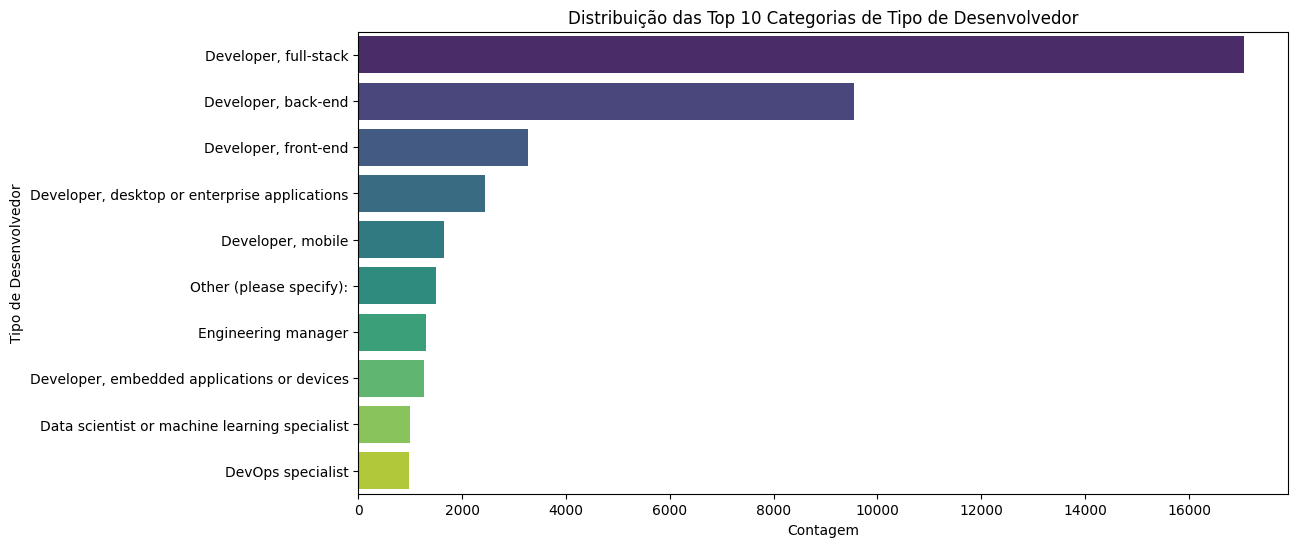

In [141]:
# TOP 10 CATEGORIAS DE TIPO DE DESENVOLVEDOR:
plt.figure(figsize=(12, 6))
sns.countplot(y=dev_types_exploded, order=top_dev_types.index[:10], palette='viridis')
plt.title('Distribuição das Top 10 Categorias de Tipo de Desenvolvedor')
plt.xlabel('Contagem')
plt.ylabel('Tipo de Desenvolvedor')
plt.show()

In [142]:
# NÚMERO DE TOP CATEGORIAS A SEREM CONSIDERADAS
num_top_dev_types = 10

# OBTER O NUM_TOP_DEV_TYPES CATEGORIAS DE DESENVOLVEDOR:
top_dev_types_list = top_dev_types.head(num_top_dev_types).index.tolist()
print(f"\nCriando features binárias para as top {num_top_dev_types} tipos de desenvolvedor:")
print(top_dev_types_list)


Criando features binárias para as top 10 tipos de desenvolvedor:
['Developer, full-stack', 'Developer, back-end', 'Developer, front-end', 'Developer, desktop or enterprise applications', 'Developer, mobile', 'Other (please specify):', 'Engineering manager', 'Developer, embedded applications or devices', 'Data scientist or machine learning specialist', 'DevOps specialist']


In [143]:
# ONE-HOT ENCODING PARA OS TIPOS DE DESENVOLVEDORES:
for dev_type in top_dev_types_list:
    # 1 SE 'DevType' POSSUIR ALGUMA COISA, 0 CASO CONTRÁRIO
    df_log[f'DevType_{dev_type.replace(" ", "_").replace(",", "").replace("-", "_").lower()}'] = \
        df_log['DevType'].astype(str).str.contains(dev_type, na=False).astype(int)

# DROP DA COLUNA ORIGINAL 'DevType':
df_log = df_log.drop('DevType', axis=1)

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_16032\1775423410.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_log['DevType'].astype(str).str.contains(dev_type, na=False).astype(int)


## 6.2. Análise e Pré-processamento da Feature 'OrgSize':

In [144]:
# VALORES AUSENTES:
print(f"Valores ausentes: {df_log['OrgSize'].isnull().sum()} ({df_log['OrgSize'].isnull().sum() / len(df_log) * 100:.2f}%)")

# CONTAGEM DE VALORES ÚNICOS E SUAS FREQUÊNCIAS:
print("\nContagem de Tamanho da Organização:")
print(df_log['OrgSize'].value_counts())
print(f"Número total de categorias únicas: {df_log['OrgSize'].nunique()}")

Valores ausentes: 37 (0.08%)

Contagem de Tamanho da Organização:
OrgSize
20 to 99 employees                                    10310
100 to 499 employees                                   9518
10,000 or more employees                               6099
1,000 to 4,999 employees                               5702
2 to 9 employees                                       4318
10 to 19 employees                                     3886
500 to 999 employees                                   3450
5,000 to 9,999 employees                               2063
Just me - I am a freelancer, sole proprietor, etc.     2054
I don’t know                                            582
Name: count, dtype: int64
Número total de categorias únicas: 10


C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_16032\3225189289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_log['OrgSize'], order=df_log['OrgSize'].value_counts().index, palette='viridis')


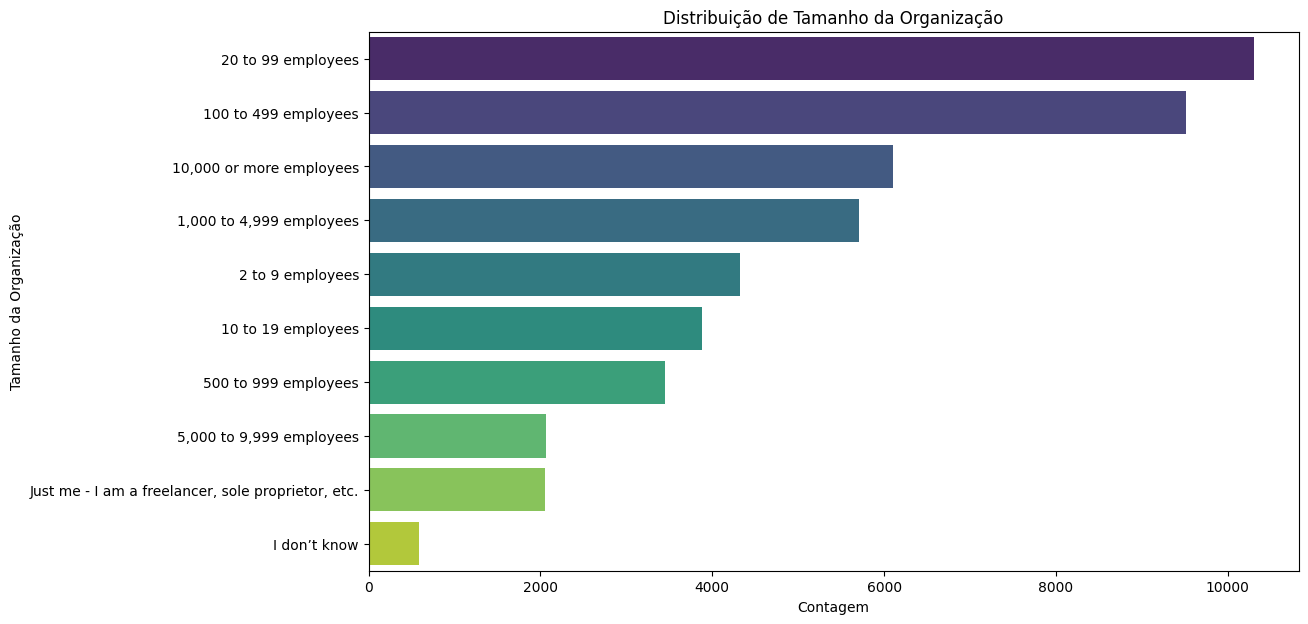

In [145]:
# DISTRIBUIÇÃO DAS CATEGORIAS:
plt.figure(figsize=(12, 7)) # Ajustei o tamanho para melhor visualização
sns.countplot(y=df_log['OrgSize'], order=df_log['OrgSize'].value_counts().index, palette='viridis')
plt.title('Distribuição de Tamanho da Organização')
plt.xlabel('Contagem')
plt.ylabel('Tamanho da Organização')
plt.show()

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_16032\3196155046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ConvertedCompYearly_log', y='OrgSize', data=df_log.dropna(subset=['OrgSize']), order=df_log['OrgSize'].value_counts().index, palette='viridis')


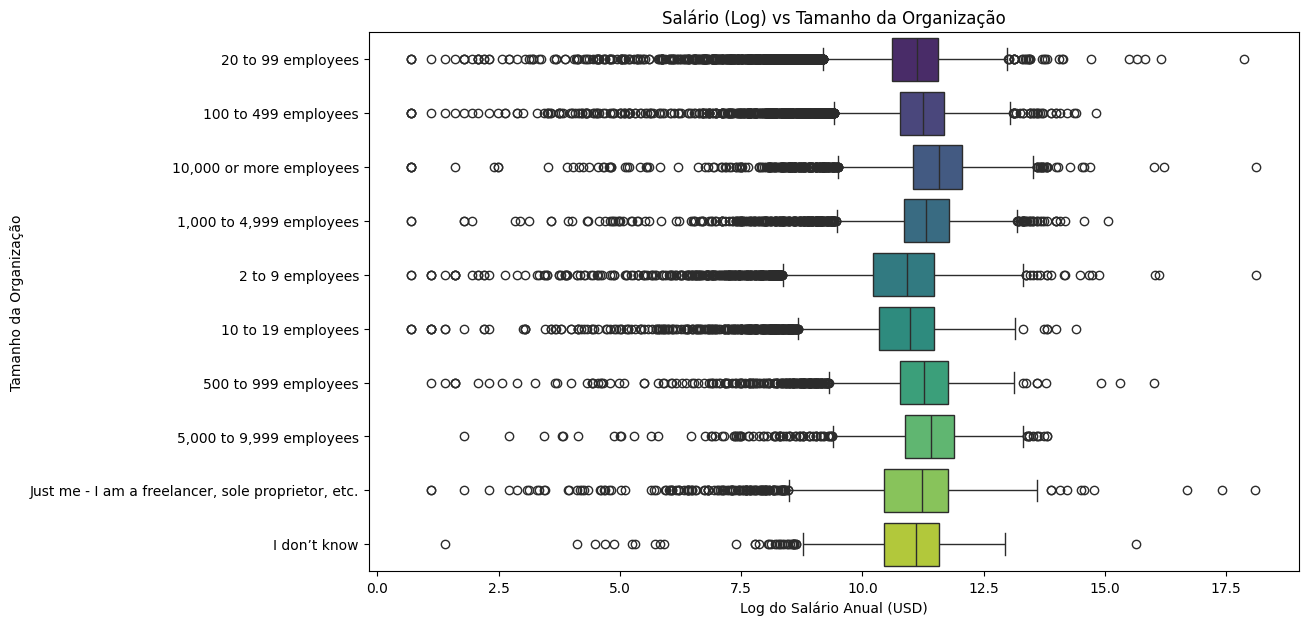

In [146]:
# BOXPLOT PARA A RELAÇÃO ENTRE TIPO DE ORGANIZAÇÃO E SALÁRIO (LOG):
plt.figure(figsize=(12, 7)) # Ajustei o tamanho
sns.boxplot(x='ConvertedCompYearly_log', y='OrgSize', data=df_log.dropna(subset=['OrgSize']), order=df_log['OrgSize'].value_counts().index, palette='viridis')
plt.title('Salário (Log) vs Tamanho da Organização')
plt.xlabel('Log do Salário Anual (USD)')
plt.ylabel('Tamanho da Organização')
plt.show()

In [147]:
# MÉDIA DO LOG DO SALÁRIO POR TAMANHO DA ORGANIZAÇÃO:
print(df_log.groupby('OrgSize')['ConvertedCompYearly_log'].mean().sort_values(ascending=False))

OrgSize
10,000 or more employees                              11.447878
5,000 to 9,999 employees                              11.293894
1,000 to 4,999 employees                              11.206305
500 to 999 employees                                  11.095285
100 to 499 employees                                  11.063414
20 to 99 employees                                    10.879917
Just me - I am a freelancer, sole proprietor, etc.    10.870319
I don’t know                                          10.827007
10 to 19 employees                                    10.665906
2 to 9 employees                                      10.626510
Name: ConvertedCompYearly_log, dtype: float64


In [148]:
df_log['OrgSize'].value_counts()

OrgSize
20 to 99 employees                                    10310
100 to 499 employees                                   9518
10,000 or more employees                               6099
1,000 to 4,999 employees                               5702
2 to 9 employees                                       4318
10 to 19 employees                                     3886
500 to 999 employees                                   3450
5,000 to 9,999 employees                               2063
Just me - I am a freelancer, sole proprietor, etc.     2054
I don’t know                                            582
Name: count, dtype: int64

In [149]:
# MAPEAMENTO MANUAL PARA 'OrgSize' DO MENOR PARA O MAIOR
org_size_mapping = {
    '2 to 9 employees': 0,
    '10 to 19 employees': 1,
    "I don't know": 2, # Posicionado aqui com base na média salarial
    'Just me - I am a freelancer, sole proprietor, etc.': 3, # Posicionado aqui com base na média salarial
    '20 to 99 employees': 4,
    '100 to 499 employees': 5,
    '500 to 999 employees': 6,
    '1,000 to 4,999 employees': 7,
    '5,000 to 9,999 employees': 8,
    '10,000 or more employees': 9
}

# CRIAÇÃO DE UMA NOVA COLUNA NUMÉRICA PARA O 'OrgSize':
df_log['OrgSize_Numeric'] = df_log['OrgSize'].map(org_size_mapping)

In [150]:
# VALORES APÓS A TRANSFORMAÇÃO:
print("\nValores únicos em 'OrgSize_Numeric' após transformação:")
print(df_log['OrgSize_Numeric'].value_counts())

# DTYPE DA NOVA COLUNA:
print("\nTipo de dado de 'OrgSize_Numeric':", df_log['OrgSize_Numeric'].dtype)

# VALORES NULOS:
print(f"\nValores ausentes em 'OrgSize_Numeric': {df_log['OrgSize_Numeric'].isnull().sum()} "
      f"({df_log['OrgSize_Numeric'].isnull().sum() / len(df_log) * 100:.2f}%)")


Valores únicos em 'OrgSize_Numeric' após transformação:
OrgSize_Numeric
4.0    10310
5.0     9518
9.0     6099
7.0     5702
0.0     4318
1.0     3886
6.0     3450
8.0     2063
3.0     2054
Name: count, dtype: int64

Tipo de dado de 'OrgSize_Numeric': float64

Valores ausentes em 'OrgSize_Numeric': 619 (1.29%)


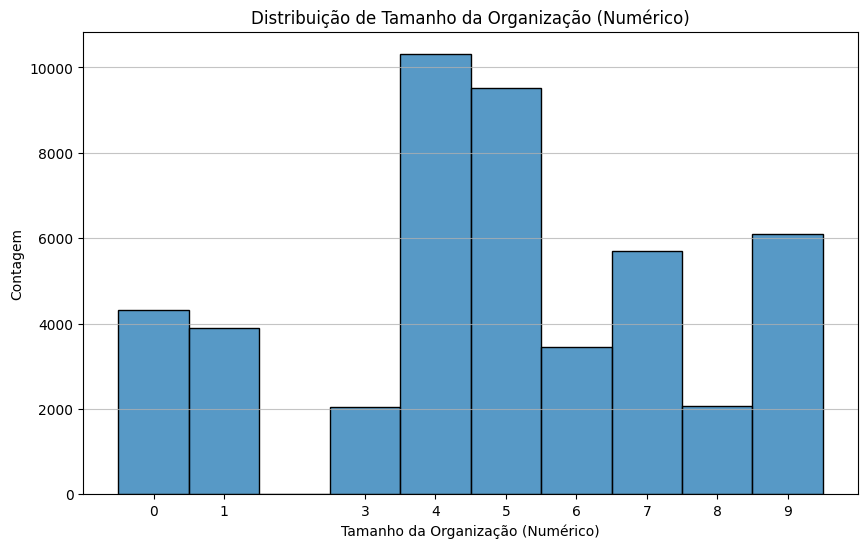

In [151]:
# DISTRIBUIÇÃO DA COLUNA TRANSFORMADA:
plt.figure(figsize=(10, 6))
sns.histplot(df_log['OrgSize_Numeric'].dropna(), bins=df_log['OrgSize_Numeric'].nunique(), kde=False, discrete=True)
plt.title('Distribuição de Tamanho da Organização (Numérico)')
plt.xlabel('Tamanho da Organização (Numérico)')
plt.ylabel('Contagem')
plt.xticks(sorted(df_log['OrgSize_Numeric'].dropna().unique()))
plt.grid(axis='y', alpha=0.75)
plt.show()

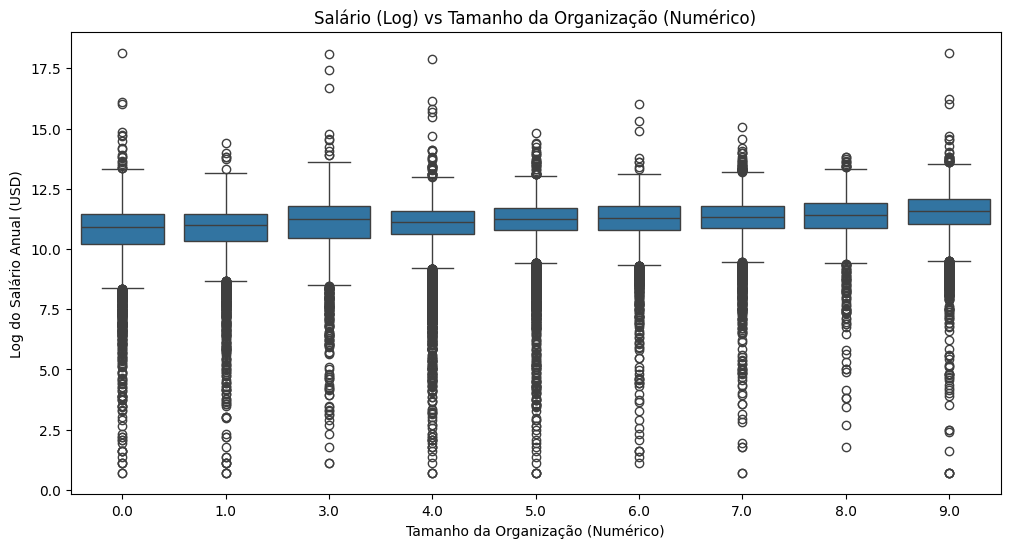

In [152]:
# BOXPLOT PARA A RELAÇÃO ENTRE TAMANHO DA ORGANIZAÇÃO (NUMÉRICO) E SALÁRIO (LOG):
plt.figure(figsize=(12, 6))
sns.boxplot(x='OrgSize_Numeric', y='ConvertedCompYearly_log', data=df_log.dropna(subset=['OrgSize_Numeric']))
plt.title('Salário (Log) vs Tamanho da Organização (Numérico)')
plt.xlabel('Tamanho da Organização (Numérico)')
plt.ylabel('Log do Salário Anual (USD)')
plt.show()

In [153]:
# MÉDIA DO LOG DO SALÁRIO POR TAMANHO DA ORGANIZAÇÃO (NUMÉRICO):
print("\nMédia do Log do Salário por Tamanho da Organização (Numérico):")
print(df_log.groupby('OrgSize_Numeric')['ConvertedCompYearly_log'].mean().sort_index())


Média do Log do Salário por Tamanho da Organização (Numérico):
OrgSize_Numeric
0.0    10.626510
1.0    10.665906
3.0    10.870319
4.0    10.879917
5.0    11.063414
6.0    11.095285
7.0    11.206305
8.0    11.293894
9.0    11.447878
Name: ConvertedCompYearly_log, dtype: float64


# 7. MODELAGEM:

Text(0.5, 1.0, 'Mapa de Correlação entre Variáveis Numéricas')

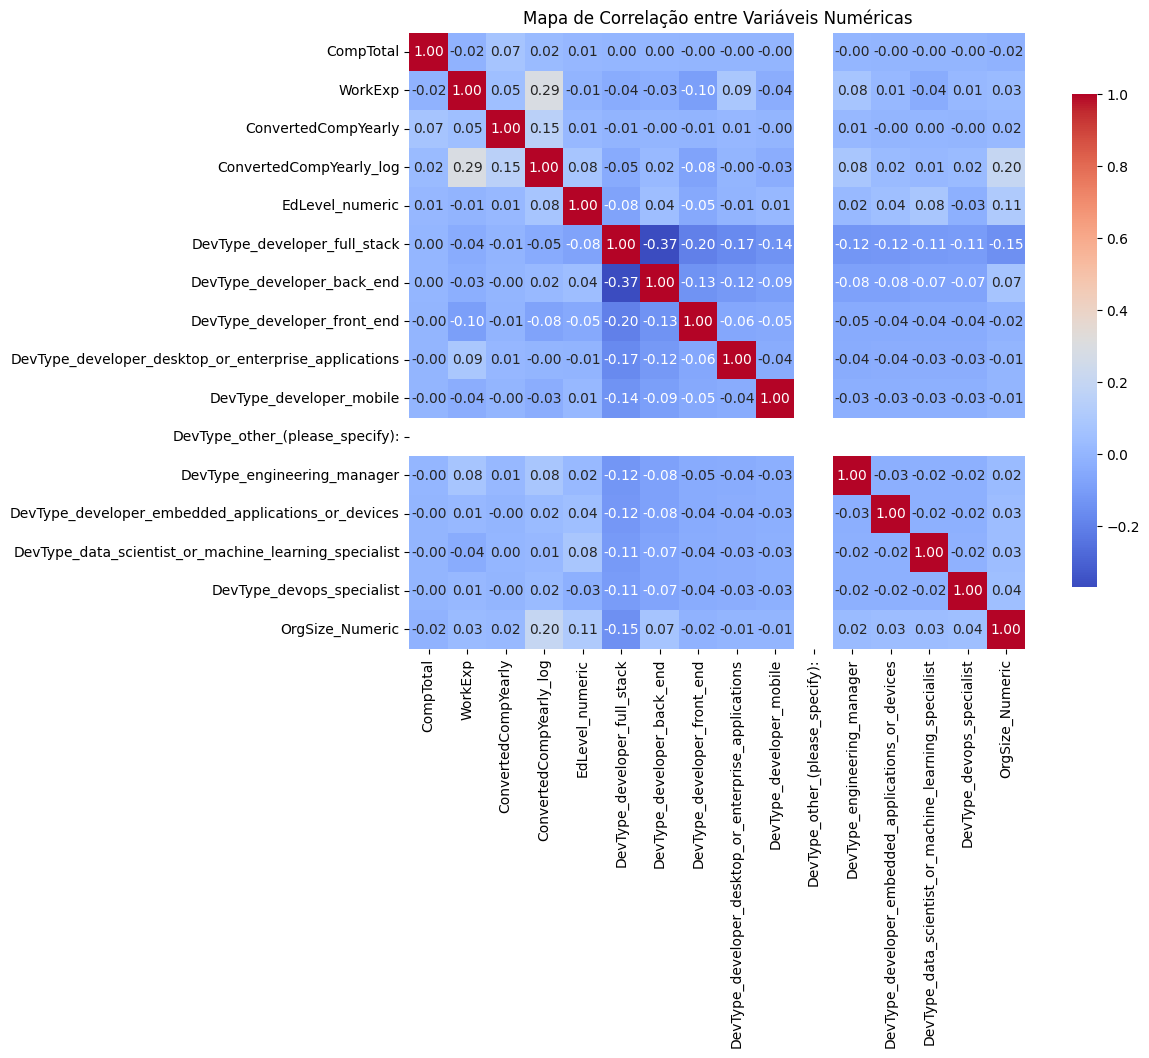

In [154]:
# SELECIONAR COLUNAS NUMÉRICAS PARA ANÁLISE:
colunas_numericas = df_log.select_dtypes(include=['int64', 'float64']).columns.tolist()

# MATRIZ DE CORRELAÇÃO:
correlacao = df_log[colunas_numericas].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Mapa de Correlação entre Variáveis Numéricas')   

In [155]:
# SELECIONAR APENAS AS COLUNAS COM CORRELAÇÃO MAIOR QUE 0.1 COM O TARGET (ConvertedCompYearly_log):
colunas_selecionadas = correlacao[correlacao['ConvertedCompYearly_log'].abs() > 0.04].index.tolist()
colunas_selecionadas

['WorkExp',
 'ConvertedCompYearly',
 'ConvertedCompYearly_log',
 'EdLevel_numeric',
 'DevType_developer_full_stack',
 'DevType_developer_front_end',
 'DevType_engineering_manager',
 'OrgSize_Numeric']

In [160]:
# REMOÇÃO DOS VALORES NULOS:
df_log.dropna(subset=colunas_selecionadas, inplace=True)

In [162]:
# TARGET E FEATURES:
X = df_log[colunas_selecionadas].drop(columns=['ConvertedCompYearly_log'])
y = df_log['ConvertedCompYearly_log']

# SPLIT DE TREINO E TESTE:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")


Tamanho do conjunto de treino (X_train): (23740, 7)
Tamanho do conjunto de teste (X_test): (5936, 7)


In [163]:
# MODELO: REGRESSÃO LINEAR
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [164]:
# PREDIÇÃO E AVALIAÇÃO:
y_pred = linear_model.predict(X_test)

# MÉTRICAS DE AVALIAÇÃO:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétricas de Avaliação do Modelo:")
print(f"MAE (Teste): {mae:.4f}")
print(f"MSE (Teste): {mse:.4f}")
print(f"RMSE (Teste): {rmse:.4f}")
print(f"R² (Teste): {r2:.4f}")


Métricas de Avaliação do Modelo:
MAE (Teste): 0.6236
MSE (Teste): 1.0466
RMSE (Teste): 1.0230
R² (Teste): 0.3073


# 8. COEFICIENTES:


Coeficientes do Modelo:
                        Feature  Coefficient  Abs_Coefficient
5   DevType_engineering_manager     0.273793         0.273793
4   DevType_developer_front_end    -0.231506         0.231506
6               OrgSize_Numeric     0.070813         0.070813
2               EdLevel_numeric     0.041588         0.041588
0                       WorkExp     0.032199         0.032199
3  DevType_developer_full_stack    -0.004642         0.004642
1           ConvertedCompYearly     0.000003         0.000003


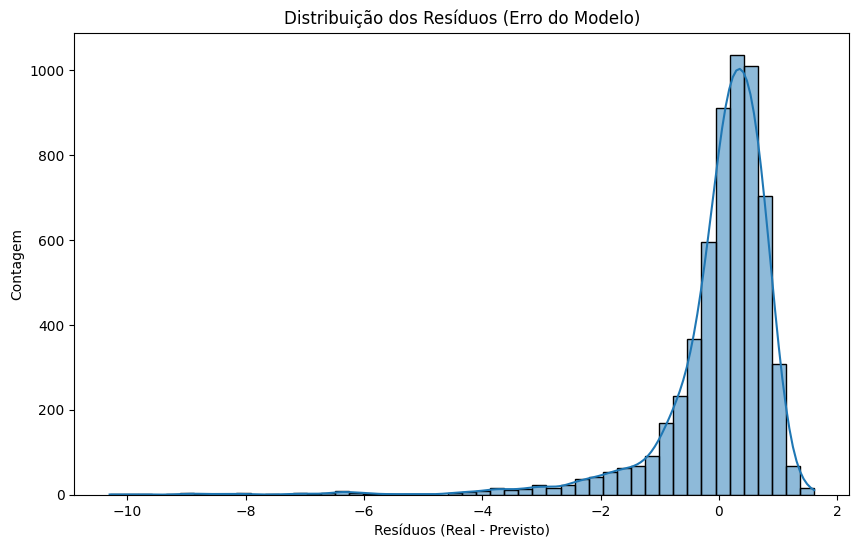

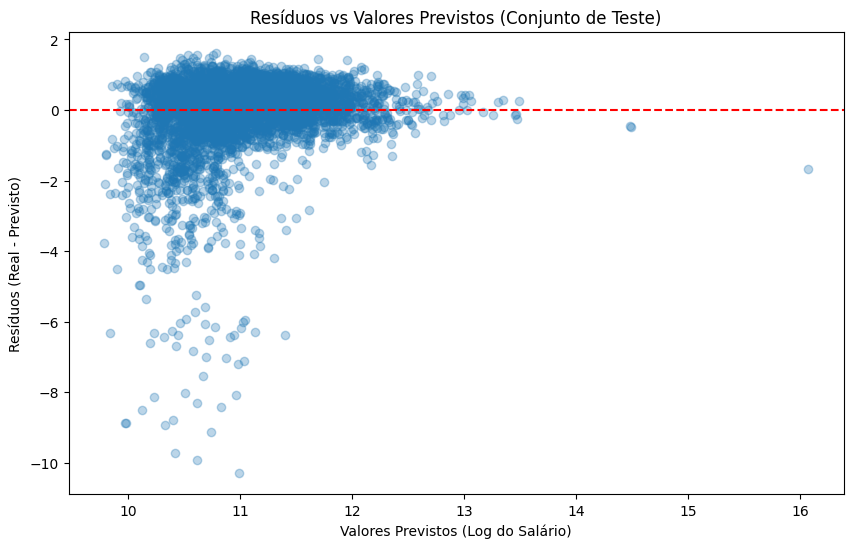

In [165]:
print("\nCoeficientes do Modelo:")
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': linear_model.coef_})
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
print(coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(10)) # Top 10 maiores coeficientes

# Visualização de Resíduos (Erro) - Apenas para o conjunto de teste
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, bins=50, kde=True)
plt.title('Distribuição dos Resíduos (Erro do Modelo)')
plt.xlabel('Resíduos (Real - Previsto)')
plt.ylabel('Contagem')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs Valores Previstos (Conjunto de Teste)')
plt.xlabel('Valores Previstos (Log do Salário)')
plt.ylabel('Resíduos (Real - Previsto)')
plt.show()